# Parte 1: Preparación del Entorno 

Aunque en las instrucciones se propone utilizar Google Colab con GPU, durante el desarrollo de esta práctica opté por trabajar principalmente en mi entorno local. Esta decisión se basó en razones técnicas relacionadas con el control del entorno de desarrollo y la eficiencia del proceso de experimentación.

En mi equipo dispongo de un entorno Python configurado previamente con las versiones específicas de TensorFlow, Keras y las dependencias necesarias para proyectos de aprendizaje profundo. Trabajar en este entorno me permite mantener una configuración estable y reproducible, evitando variaciones en dependencias o cambios de versión que a veces pueden ocurrir en entornos gestionados como Colab.

El desarrollo se realizó en un equipo con GPU NVIDIA compatible con CUDA, utilizando la aceleración por hardware proporcionada por la plataforma CUDA y la librería cuDNN. Esta configuración permite que TensorFlow ejecute operaciones de aprendizaje profundo directamente en la GPU, lo que mejora significativamente el rendimiento en tareas de entrenamiento de modelos. Gracias a esta aceleración, es posible procesar de forma más eficiente operaciones intensivas como multiplicaciones de matrices, cálculo de gradientes y propagación hacia atrás en redes neuronales.

Además, al ejecutar el código localmente tengo un control más directo sobre el uso de recursos y el flujo de trabajo de desarrollo. Esto facilita la depuración del modelo, la iteración rápida sobre cambios en la arquitectura del Transformer y la experimentación con hiperparámetros, ya que el entorno permanece persistente entre ejecuciones.

Otro factor relevante es la integración con herramientas de desarrollo que utilizo habitualmente, como el gestor de entornos, el control de versiones y el editor de código. Esta integración mejora la trazabilidad de los cambios realizados en el modelo y permite organizar el proceso de experimentación de forma más estructurada.

En términos de resultados, el entrenamiento del modelo sobre el dataset proporcionado (1.079 titulares) no requiere necesariamente grandes recursos computacionales. No obstante, el uso de aceleración mediante GPU con CUDA permite reducir los tiempos de entrenamiento y facilita la realización de múltiples experimentos con distintas configuraciones del modelo.

Por estas razones, aunque el código es totalmente compatible con Google Colab, el desarrollo principal de la práctica se realizó en un entorno local configurado específicamente para proyectos de machine learning con aceleración por GPU.

In [1]:
# Verificar GPU en Colab
import tensorflow as tf
print("GPU disponible:", tf.config.list_physical_devices('GPU'))

# Imports
import numpy as np
import keras
from keras import layers
import matplotlib.pyplot as plt



# Descargar dataset
!gdown 199dxi24ln2b-_S4mhH2sgpr3nvxmoxZN -O titulares.txt

# Cargar texto
with open('titulares.txt', 'r', encoding='utf-8') as f:
    text = f.read()

print(f"Caracteres totales: {len(text)}")
print(f"Muestra:\n{text[:500]}")

2026-03-08 23:49:19.686530: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-03-08 23:49:19.735780: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI AVX512_BF16 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-03-08 23:49:20.519240: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


GPU disponible: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
Downloading...
From: https://drive.google.com/uc?id=199dxi24ln2b-_S4mhH2sgpr3nvxmoxZN
To: /home/acalde/titulares.txt
100%|██████████████████████████████████████| 60.4k/60.4k [00:00<00:00, 2.56MB/s]
Caracteres totales: 60438
Muestra:
nueva ley de energia promete revolucionar el sector electrico
el cambio climatico sigue siendo una amenaza global
inversionistas buscan oportunidades en energias renovables
aumenta la demanda de vehiculos electricos
vacunas contra covid19 cuando estaremos todos protegidos
el debate sobre las vacunas sigue dividiendo opiniones
expertos en salud analizan la efectividad de las vacunas
vacunacion masiva contra el coronavirus en marcha
el mercado de criptomonedas se dispara a nuevas alturas
es bitcoi


# Parte 2: Tokenización a Nivel de Carácter

In [2]:
# Crear vocabulario
vocab = sorted(set(text))
vocab_size = len(vocab)
print(f"Vocabulario: {vocab_size} caracteres únicos")

# Mapeos
char_to_idx = {ch: i for i, ch in enumerate(vocab)}
idx_to_char = {i: ch for i, ch in enumerate(vocab)}

def encode(s):
    return [char_to_idx[c] for c in s]

def decode(ids):
    return ''.join([idx_to_char[i] for i in ids])

# Test
# "Hola" No se encuentra en el vocabulario, saca un error, por eso se ha puesto "hola"
# Test
# Se usa "hola" en lugar de "Hola" porque el vocabulario se construye
# únicamente con los caracteres presentes en el dataset. Si un carácter
# no aparece en el corpus (por ejemplo una 'H' mayúscula), no existirá
# en el diccionario char_to_idx y Python generará un KeyError.
# No hay ninguna letra en mayúscula en el vocabulario.

encoded = encode("hola")
print(encoded)
print(decode(encoded))

Vocabulario: 33 caracteres únicos
[15, 22, 19, 8]
hola


# Parte 3: Preparar Datos de Entrenamiento (15 min)

In [3]:
# Parámetros
SEQ_LENGTH = 80
BATCH_SIZE = 64

# Tokenizar todo
tokens = np.array(encode(text))

# Crear secuencias X, y
def crear_secuencias(tokens, seq_len):
    X, y = [], []
    for i in range(len(tokens) - seq_len):
        X.append(tokens[i:i+seq_len])
        y.append(tokens[i+1:i+seq_len+1])
    return np.array(X), np.array(y)

X, y = crear_secuencias(tokens, SEQ_LENGTH)
print(f"Secuencias: {X.shape}")

# Dataset de TensorFlow
dataset = tf.data.Dataset.from_tensor_slices((X, y))
dataset = dataset.shuffle(10000).batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

Secuencias: (60358, 80)


I0000 00:00:1773010163.319847   51163 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 9515 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 4070 SUPER, pci bus id: 0000:01:00.0, compute capability: 8.9


# Parte 4: Componentes del Transformer

## 4.1 Embeddings con Posición

In [4]:
class TokenAndPositionEmbedding(layers.Layer):
    def __init__(self, maxlen, vocab_size, embed_dim):
        super().__init__()
        self.token_emb = layers.Embedding(input_dim=vocab_size, output_dim=embed_dim)
        self.pos_emb = layers.Embedding(input_dim=maxlen, output_dim=embed_dim)

    def call(self, x):
        maxlen = tf.shape(x)[-1]
        positions = tf.range(start=0, limit=maxlen, delta=1)
        positions = self.pos_emb(positions)
        x = self.token_emb(x)
        return x + positions

## 4.2 Bloque Transformer con Atención Causal

In [5]:
class TransformerBlock(layers.Layer):
    def __init__(self, embed_dim, num_heads, ff_dim, dropout=0.1):
        super().__init__()
        self.att = layers.MultiHeadAttention(num_heads=num_heads, key_dim=embed_dim)
        self.ffn = keras.Sequential([
            layers.Dense(ff_dim, activation="gelu"),
            layers.Dense(embed_dim),
        ])
        self.layernorm1 = layers.LayerNormalization(epsilon=1e-6)
        self.layernorm2 = layers.LayerNormalization(epsilon=1e-6)
        self.dropout1 = layers.Dropout(dropout)
        self.dropout2 = layers.Dropout(dropout)

    def causal_attention_mask(self, batch_size, seq_len):
        """Máscara para que cada posición solo vea anteriores."""
        i = tf.range(seq_len)[:, tf.newaxis]
        j = tf.range(seq_len)
        mask = tf.cast(i >= j, dtype=tf.float32)
        mask = tf.reshape(mask, [1, 1, seq_len, seq_len])
        return tf.tile(mask, [batch_size, 1, 1, 1])

    def call(self, inputs, training=None):
        batch_size = tf.shape(inputs)[0]
        seq_len = tf.shape(inputs)[1]
        mask = self.causal_attention_mask(batch_size, seq_len)

        attn_output = self.att(inputs, inputs, attention_mask=mask)
        attn_output = self.dropout1(attn_output, training=training)
        out1 = self.layernorm1(inputs + attn_output)

        ffn_output = self.ffn(out1)
        ffn_output = self.dropout2(ffn_output, training=training)
        return self.layernorm2(out1 + ffn_output)

# Parte 5: Modelo Completo

In [6]:
EMBED_DIM = 256
NUM_HEADS = 4
FF_DIM = 512
NUM_BLOCKS = 4

def crear_modelo():
    inputs = layers.Input(shape=(SEQ_LENGTH,), dtype=tf.int32)
    x = TokenAndPositionEmbedding(SEQ_LENGTH, vocab_size, EMBED_DIM)(inputs)
    for _ in range(NUM_BLOCKS):
        x = TransformerBlock(EMBED_DIM, NUM_HEADS, FF_DIM)(x)
    outputs = layers.Dense(vocab_size, activation="softmax")(x)
    return keras.Model(inputs=inputs, outputs=outputs)

model = crear_modelo()
model.summary()

Model: "functional_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 80)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ token_and_position_embedding    │ (None, 80, 256)        │        28,928 │
│ (TokenAndPositionEmbedding)     │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ transformer_block               │ (None, 80, 256)        │     1,315,840 │
│ (TransformerBlock)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ transformer_block_1             │ (None, 80, 256)        │     1,315,840 │
│ (TransformerBlock)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ transformer_block_2             │ (None, 80, 256)        │     1,315,840 │
│ (TransformerBlock)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ transformer_block_3             │ (None, 80, 256)        │     1,315,840 │
│ (TransformerBlock)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 80, 33)         │         8,481 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 5,300,769 (20.22 MB)

 Trainable params: 5,300,769 (20.22 MB)

 Non-trainable params: 0 (0.00 B)

# Parte 6: Entrenamiento (15 min)

In [7]:
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

callbacks = [
    keras.callbacks.EarlyStopping(patience=3, restore_best_weights=True),
    keras.callbacks.ReduceLROnPlateau(factor=0.5, patience=2)
]

history = model.fit(dataset, epochs=30, callbacks=callbacks)

Epoch 1/30


2026-03-08 23:49:29.029257: I external/local_xla/xla/service/service.cc:163] XLA service 0x708e5c00d4f0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
2026-03-08 23:49:29.029293: I external/local_xla/xla/service/service.cc:171]   StreamExecutor device (0): NVIDIA GeForce RTX 4070 SUPER, Compute Capability 8.9
2026-03-08 23:49:29.145526: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
2026-03-08 23:49:30.376663: W tensorflow/compiler/tf2xla/kernels/assert_op.cc:39] Ignoring Assert operator compile_loss/sparse_categorical_crossentropy/SparseSoftmaxCrossEntropyWithLogits/assert_equal_1/Assert/Assert
2026-03-08 23:49:30.791423: I external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:473] Loaded cuDNN version 91900
2026-03-08 23:49:31.322260: I external/local_xla/xla/service/gpu/autotuning/dot_search_space.cc:208] All configs were filtered o

943/944 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 0.5136 - loss: 1.5632

2026-03-08 23:49:56.694595: W tensorflow/compiler/tf2xla/kernels/assert_op.cc:39] Ignoring Assert operator compile_loss/sparse_categorical_crossentropy/SparseSoftmaxCrossEntropyWithLogits/assert_equal_1/Assert/Assert
2026-03-08 23:49:57.451178: I external/local_xla/xla/service/gpu/autotuning/dot_search_space.cc:208] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead.
2026-03-08 23:49:57.451558: I external/local_xla/xla/service/gpu/autotuning/dot_search_space.cc:208] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead.
2026-03-08 23:49:57.772439: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled 

944/944 ━━━━━━━━━━━━━━━━━━━━ 39s 26ms/step - accuracy: 0.7232 - loss: 0.8771 - learning_rate: 0.0010
Epoch 2/30


/home/acalde/ml/lib/python3.12/site-packages/keras/src/callbacks/early_stopping.py:99: UserWarning: Early stopping conditioned on metric `val_loss` which is not available. Available metrics are: accuracy,loss
  current = self.get_monitor_value(logs)
/home/acalde/ml/lib/python3.12/site-packages/keras/src/callbacks/callback_list.py:171: UserWarning: Learning rate reduction is conditioned on metric `val_loss` which is not available. Available metrics are: accuracy,loss,learning_rate.
  callback.on_epoch_end(epoch, logs)


944/944 ━━━━━━━━━━━━━━━━━━━━ 17s 18ms/step - accuracy: 0.9003 - loss: 0.3093 - learning_rate: 0.0010
Epoch 3/30
944/944 ━━━━━━━━━━━━━━━━━━━━ 18s 19ms/step - accuracy: 0.9284 - loss: 0.2190 - learning_rate: 0.0010
Epoch 4/30
944/944 ━━━━━━━━━━━━━━━━━━━━ 17s 18ms/step - accuracy: 0.9364 - loss: 0.1930 - learning_rate: 0.0010
Epoch 5/30
944/944 ━━━━━━━━━━━━━━━━━━━━ 18s 19ms/step - accuracy: 0.9407 - loss: 0.1790 - learning_rate: 0.0010
Epoch 6/30
944/944 ━━━━━━━━━━━━━━━━━━━━ 17s 18ms/step - accuracy: 0.9434 - loss: 0.1700 - learning_rate: 0.0010
Epoch 7/30
944/944 ━━━━━━━━━━━━━━━━━━━━ 18s 19ms/step - accuracy: 0.9452 - loss: 0.1642 - learning_rate: 0.0010
Epoch 8/30
944/944 ━━━━━━━━━━━━━━━━━━━━ 17s 18ms/step - accuracy: 0.9468 - loss: 0.1586 - learning_rate: 0.0010
Epoch 9/30
944/944 ━━━━━━━━━━━━━━━━━━━━ 18s 19ms/step - accuracy: 0.9484 - loss: 0.1535 - learning_rate: 0.0010
Epoch 10/30
944/944 ━━━━━━━━━━━━━━━━━━━━ 17s 18ms/step - accuracy: 0.9492 - loss: 0.1505 - learning_rate: 0.0010
Ep

El modelo brindado presenta problemas de explosion de gradiente. En multiples ocaciones la precisión se reduce drasticamente y no se utiliza early stopping correctamente. 

## Visualizacion de la Curvas de Entrenamiento

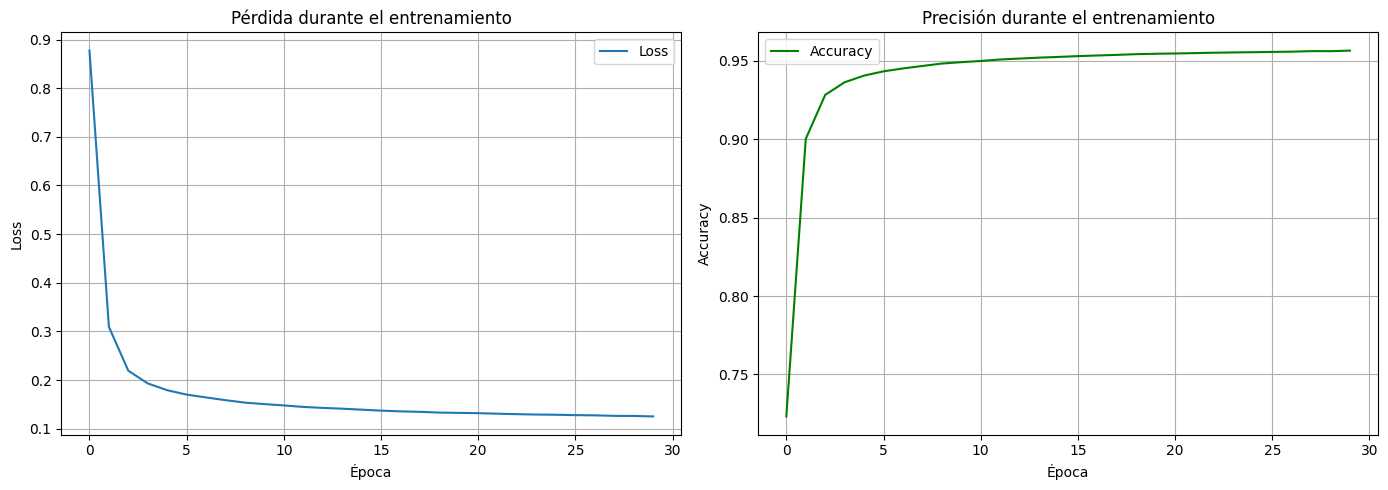

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Pérdida
axes[0].plot(history.history['loss'], label='Loss')
axes[0].set_title('Pérdida durante el entrenamiento')
axes[0].set_xlabel('Época')
axes[0].set_ylabel('Loss')
axes[0].legend()
axes[0].grid(True)

# Precisión
axes[1].plot(history.history['accuracy'], label='Accuracy', color='green')
axes[1].set_title('Precisión durante el entrenamiento')
axes[1].set_xlabel('Época')
axes[1].set_ylabel('Accuracy')
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.show()

# Parte 7: Generación de Texto 

In [9]:
def generar_texto(model, inicio, longitud=100, temperatura=1.0):
    """Genera texto de forma autoregresiva."""
    generado = list(encode(inicio))

    for _ in range(longitud):
        input_seq = generado[-SEQ_LENGTH:]
        input_seq = np.array(input_seq)[np.newaxis, :]

        if len(input_seq[0]) < SEQ_LENGTH:
            pad_len = SEQ_LENGTH - len(input_seq[0])
            input_seq = np.pad(input_seq, ((0,0), (pad_len, 0)))

        preds = model.predict(input_seq, verbose=0)[0, -1, :]

        preds = np.log(preds + 1e-10) / temperatura
        preds = np.exp(preds) / np.sum(np.exp(preds))

        next_idx = np.random.choice(len(preds), p=preds)
        generado.append(next_idx)

        if idx_to_char[next_idx] == '\n':
            break

    return decode(generado)

# Generar con diferentes temperaturas
print("=== Temperatura 0.5 ===")
print(generar_texto(model, "el gobierno ", temperatura=0.5))

print("\n=== Temperatura 1.0 ===")
print(generar_texto(model, "el gobierno ", temperatura=1.0))

print("\n=== Temperatura 1.5 ===")
print(generar_texto(model, "el gobierno ", temperatura=1.5))

=== Temperatura 0.5 ===


2026-03-08 23:58:23.168808: I external/local_xla/xla/service/gpu/autotuning/dot_search_space.cc:208] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead.
2026-03-08 23:58:23.168985: I external/local_xla/xla/service/gpu/autotuning/dot_search_space.cc:208] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead.
2026-03-08 23:58:23.427961: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_42', 4 bytes spill stores, 4 bytes spill loads

2026-03-08 23:58:23.620428: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Reg

el gobierno de la coservacion de los ecosistemas marinos protegiendo nuestros oceanos


=== Temperatura 1.0 ===
el gobierno de la seguridad de la moda y abilidad eleccion consciente


=== Temperatura 1.5 ===
el gobierno de la contaminacion y al cambion hacia la sostenibilidad



In [10]:
inicios = ["la economia ", "un nuevo ", "el presidente ", "argentina ", "se espera "]

for inicio in inicios:
    print(f"Inicio: '{inicio}'")
    print(f"  → {generar_texto(model, inicio, temperatura=0.8)}")
    print()

Inicio: 'la economia '
  → la economia los protegiendo nuestros oceanos protegiendo nuestros tesoros marinos


Inicio: 'un nuevo '
  → un nuevo trenestir y fgrestion eficiente de recursos con ia


Inicio: 'el presidente '
  → el presidente demanda de studiantes para un mundo digital interconectado


Inicio: 'argentina '
  → argentina responsabilidad hacia los mares y su vida marina


Inicio: 'se espera '
  → se espera seguridad que priorizan la sostenibilidad y la justicia social




# Implementación de Mini-GPT con TensorFlow/Keras

**Nota sobre la estructura de la entrega**

Durante el desarrollo del ejercicio se realizó una mejora del código original en un segundo notebook dentro de la misma carpeta.

La entrega final está compuesta por ambos notebooks:

- `ejercicio.ipynb`: contiene la implementación base siguiendo la consigna del ejercicio.
- `mini_gpt_mejorado.ipynb`: contiene una versión refactorizada y más robusta del mismo modelo, con mejoras en:
  - organización del código
  - estabilidad del entrenamiento
  - implementación del bloque Transformer
  - generación de texto
  - documentación y análisis del experimento

La solución presentada es una **combinación conceptual de ambas versiones**.  
El notebook mejorado incluye explicaciones adicionales sobre el funcionamiento de cada componente del modelo, así como una reflexión más detallada sobre el comportamiento del Mini-GPT entrenado.

De esta forma se mantiene el desarrollo original del ejercicio y, al mismo tiempo, se presenta una versión técnicamente más sólida del modelo.